# Uncertainty estimate

In this notebook we find a measure of the accuracy of any admissions predictions we make from the derived coefficients. We do this by using the coefficients to calculate the admissions numbers in each MSOA, comparing the results with the real-life observed values, and measuring the typical difference between predicted and observed values.

We select groups of MSOAs that give roughly the same number of predicted stroke admissions. Their real-life observed admission numbers will naturally contain some variations from this predicted number. We expect that most MSOA have observed admissions quite close to the prediction and that others will be quite a bit larger or smaller. We can take the standard deviation of the observed admissions as a measure of the spread of values.

__Inputs__

+ MSOA-level admission numbers, numbers of people in each age band.
+ Probability of stroke given age band, i.e. SSNAP-derived coefficients
+ Total number of admissions in each age band from SSNAP
+ Best set of coefficients after nudging the values.

__Method__

Use the derived coefficients to calculate the admissions numbers for each MSOA.

Round the predicted admissions to the nearest whole number. Gather the MSOAs whose predicted admissions round to the same number.

To check the distribution of the observed admissions, plot a histogram of the observed admissions for each of these groups. The shape of the graph looks like a Poisson distribution, so overplot a normal distribution with the same mean and standard deviation as the observed admissions here. The normal distribution gives the best fit to the data for groups that contain at least 200 MSOAs.

Take the groups with at least 200 MSOAs. Collect their standard deviations. Fit a straight line to the standard deviation $s$ as a function of the predicted admissions $x$ to find $s = 0.13x + 1.30$.

Apply the standard deviation fit to all of the groups, including the ones with fewer than 200 MSOAs. Use this as a measure of the expected variation from the predicted values.

__Results__

The standard deviation $s$ of the observed admission values for a group of MSOA with predicted admissions $x$ is $s = 0.13x + 1.30$.

## Code setup

In [100]:
import polars as pl
import os
import numpy as np

# For plotting:
import matplotlib.pyplot as plt
import matplotlib.ticker  # for axis tick location

from scipy.stats import norm  # for normal distribution
import statsmodels.api as sm  # for ordinary least squares

## Load data

### Admissions

In [101]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [102]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [103]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}'
               for q in qmin_list for a in age_numbers]
# Check the first few:
print(coeff_names[:3])

# Quantile names:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))

['age_less65_q00', 'age_65_q00', 'age_70_q00']


Gather admissions data by deprivation quantile:

In [104]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Best coefficients

In [105]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

Pick out best set of coefficients:

In [106]:
df_best_coeffs = df_best_nudged.filter(df_best_nudged['fitness'] == df_best_nudged['fitness'].min())[0]

In [107]:
df_best_coeffs

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08,dir
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed09"""


Convert to array:

In [108]:
best_coeffs = df_best_coeffs[coeff_names].to_numpy().flatten()

In [109]:
best_coeffs.reshape(5, 5)

array([[0.0006, 0.005 , 0.005 , 0.007 , 0.012 ],
       [0.0005, 0.003 , 0.004 , 0.007 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.005 , 0.011 ],
       [0.0003, 0.002 , 0.002 , 0.005 , 0.011 ]])

## Recalculate admissions

The usual function to calculate admissions:

In [110]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

Calculate the admissions using that function:

In [111]:
# Predictions for each MSOA:
predictions_lists = []
for i in range(5):
    coeffs = best_coeffs[(i*5):(i*5)+5]  # coeffs for this depriv.
    yhat = predict_admissions(x_lists[i], coeffs)
    # Difference from actual:
    predictions_lists.append(yhat)
    
# Combine lists:
observed_all = sum(admissions_lists, [])
predicted_all = sum(predictions_lists, [])

Compare the observed (real data) with the predicted (using the coefficients) admissions:

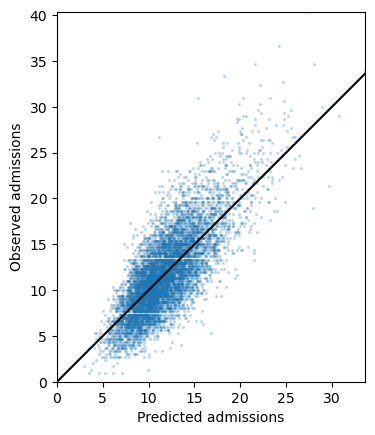

In [112]:
fig, ax = plt.subplots()

ax.scatter(predicted_all, observed_all, s=2, alpha=0.2)
ax.plot([0, max(observed_all)], [0, max(observed_all)], color='k')

ax.set_aspect('equal')
ax.set_ylabel('Observed admissions')
ax.set_xlabel('Predicted admissions')

ax.set_ylim(0, max(observed_all))
ax.set_xlim(0, max(predicted_all))
plt.show()

## Slice bins

Set up the bins. Make them so that values will be grouped to their nearest whole number, e.g. the 13 bin will contain MSOA with predicted admissions numbers from 12.5 (inclusive) to 13.5 (exclusive) admissions.

In [113]:
# Set up bins with left/right edges between every whole number,
# so the bin middle values are all whole numbers from 0 to
# the number required so that every MSOA has a home:
bins = np.arange(-0.5, np.ceil(max(predicted_all))+0.5, 1.0)
bin_mids = bins + 0.5

# View bins:
bins

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5])

Use `digitize` to work out which bin each MSOA belongs to. Then make separate lists for each bin to group the MSOA data. Make a list for each group of MSOA's predicted and observed admissions numbers.

In [114]:
# Find which bin each value of predicted admissions belongs in.
# The index of each selected bin (its position in the list) is stored
# in bin_inds.
bin_inds = np.digitize(predicted_all, bins)
# In this list, bin index 0 will be for under -0.5 admissions (which
# shouldn't happen here!). Bin index 1 is for -0.5 (inclusive) to +0.5
# (exclusive).

# Store results as dict of lists:
binned_admissions = {}
binned_predictions = {}
# For each bin in turn, gather the values that belong in it.
for b, bin_left in enumerate(bins):
    # What is the middle of this bin?
    bin_mid = bin_mids[b]
    # Which items in the lists belong in this bin?
    # Add 1 because the first bin (when b=0) is labelled with
    # index 1 in bin_inds.
    p = np.where(bin_inds == b+1)
    # Pick out those items into their own separate list
    # and add them to the dictionary:
    binned_admissions[bin_mid] = np.array(observed_all)[p]
    binned_predictions[bin_mid] = np.array(predicted_all)[p]

Calculate useful statistics for each group. Find its mean, standard deviation, and the number of MSOA in the group.

In [115]:
# Place the results in this dictionary:
dict_stats = dict(
    bin_mids = [],
    means = [],
    stds = [],
    variances = [],
    lengths = [],
)
# Calculate stats and place in the dictionary:
for bin_mid, admissions in binned_admissions.items():
    dict_stats['bin_mids'].append(bin_mid)
    dict_stats['means'].append(np.mean(admissions))
    dict_stats['stds'].append(np.std(admissions))
    dict_stats['variances'].append(np.std(admissions)**2.0)
    dict_stats['lengths'].append(len(admissions))

# Convert the dictionary to a DataFrame:
df_bin_stats = pl.DataFrame()
for col, vals in dict_stats.items():
    df_bin_stats = df_bin_stats.with_columns(pl.Series(col, vals))

View the results:

In [116]:
with pl.Config(set_tbl_rows=len(df_bin_stats)):
    display(df_bin_stats)

bin_mids,means,stds,variances,lengths
f64,f64,f64,f64,i64
0.0,NaN,NaN,NaN,0
1.0,NaN,NaN,NaN,0
2.0,NaN,NaN,NaN,0
3.0,2.111111,1.133115,1.283951,3
4.0,3.583333,1.440968,2.076389,8
5.0,4.292929,1.592824,2.537088,33
6.0,5.622419,1.871225,3.501484,113
7.0,6.76378,2.103037,4.422765,254
8.0,8.010818,2.464692,6.074708,493


Bins that are empty have NaN (Not A Number) means and stds.

Generally the means are quite a good match to the predicted admissions bin middles. The match is closer for the bins in the middle of the list than for the ones near the start or end.

## Poisson over many years tests

Test of a similar plot with the same number of observations in each bin, _but_ the data is generated from a Poisson distribution.

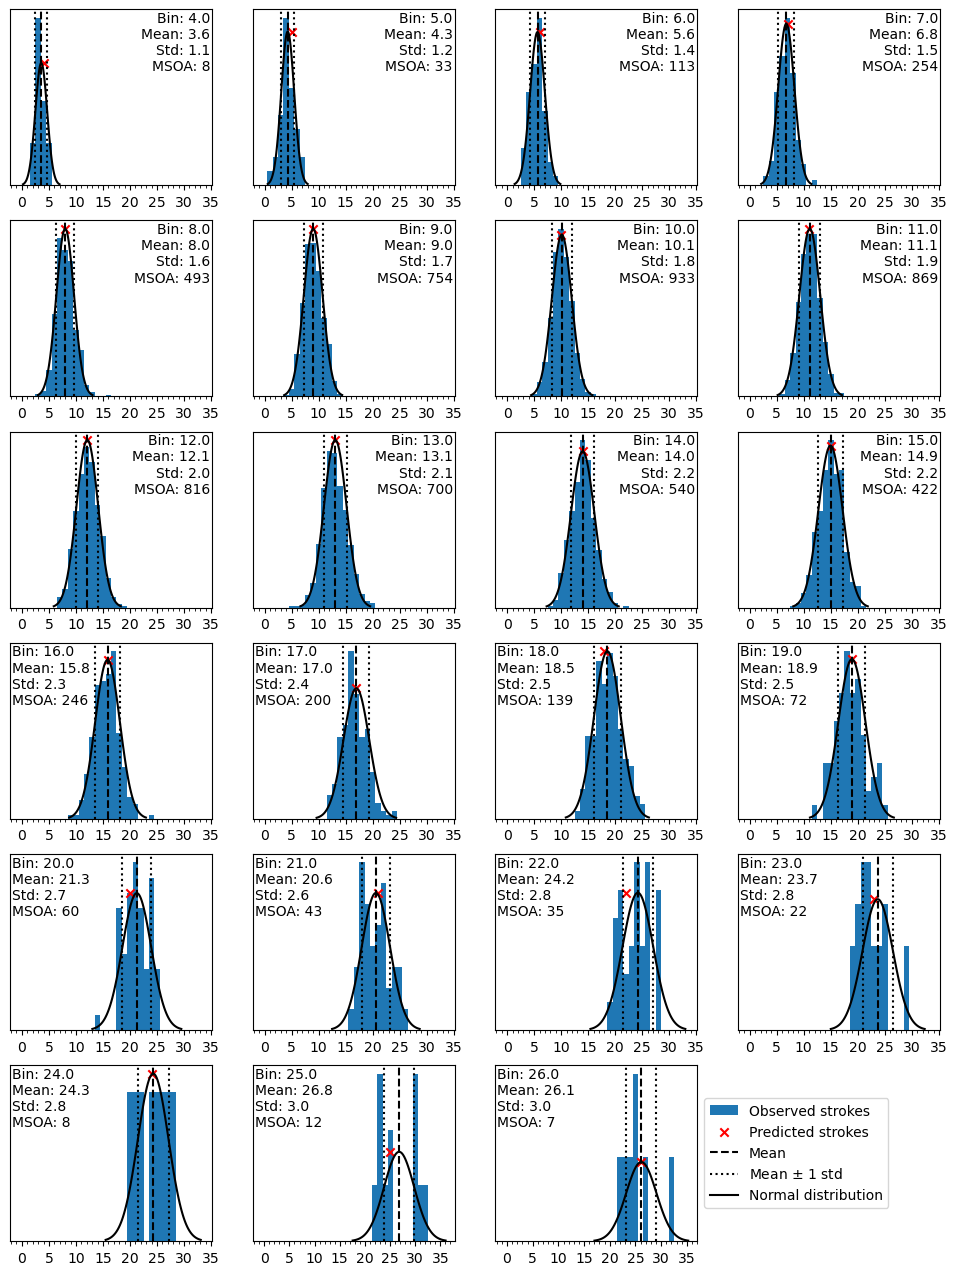

In [117]:
fig, axs = plt.subplots(6, 4, figsize=(12, 16))

# Only use bins that contain at least 5 MSOA:
df = df_bin_stats.filter(df_bin_stats['lengths'] >= 5)
# Plot each bin in turn:
for i in range(len(df)):
    # Select next available axis:
    ax = axs[i // 4, i % 4,]
    # Pick out data:
    b = df['bin_mids'][i]
    loc = df['means'][i]
    # scale = df['stds'][i]
    scale = np.sqrt(loc / 3.0)

    rng = np.random.default_rng()
    n_years = 3
    admissions_here = np.mean([rng.poisson(loc, len(binned_admissions[b])) for i in range(n_years)], axis=0)
    # admissions_here = # binned_admissions[b]


    # Create normal distribution coordinates:
    norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=scale),
                         norm.ppf(0.999, loc=loc, scale=scale), 100)
    norm_y = norm.pdf(norm_x, loc=loc, scale=scale)
    # norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=np.sqrt(loc)),
    #                      norm.ppf(0.999, loc=loc, scale=np.sqrt(loc)), 100)
    # norm_y = norm.pdf(norm_x, loc=loc, scale=np.sqrt(loc))

    # Bar chart:
    ax.hist(admissions_here, bins=bins, density=True, label='Observed strokes')
    # Mark expected mean:
    ax.scatter(b, max(norm_y), marker='x', color='r', linestyle='-', label='Predicted strokes')
    # Mark one standard deviation from the mean:
    ax.axvline(loc, color='k', linestyle='--', label='Mean')
    ax.axvline(loc + scale, color='k', linestyle=':', label=r'Mean $\pm$ 1 std')
    ax.axvline(loc - scale, color='k', linestyle=':', label=None)
    # Normal dist:
    ax.plot(norm_x, norm_y, color='k', label='Normal distribution')

    # Remove y ticks and labels.
    ax.set_yticks([])
    # Mark bin edges:
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))

    # Label each plot with the mean and std of the normal dist
    # as well as how many MSOA are in the bin.
    label = f'Bin: {b}' + '\n' + f'Mean: {loc:.1f}' + '\n' + f'Std: {scale:.1f}' + '\n' + f'MSOA: {df["lengths"][i]}'
    # Draw the label on either the top left or the top right
    # depending on where there's room:
    if i < 12:
        ax.annotate(label, xy=(0.99, 0.99), va='top', ha='right', xycoords='axes fraction')
    else:
        ax.annotate(label, xy=(0.01, 0.99), va='top', ha='left', xycoords='axes fraction')
    
    # If this is the last graph then draw the legend in the
    # gap left by the empty axis.
    if i == 22:
        ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])

# Remove the unwanted final axis:
axs[-1, -1].set_visible(False)

# plt.savefig(os.path.join('images', 'uncertainty_observed_admissions_variance.png'), bbox_inches='tight', dpi=200)
plt.show()

Fit a linear regression to the Poisson mean and variance when values are averaged over _n_ sets of samples.

In [118]:
n_samples = 200
n_bootstraps = 100

locs = np.arange(1.0, 40.0, 1.0)
n_years_list = range(1, 11, 1)

np.random.seed(42)

dict_mean_poisson = {}
for n_years in n_years_list:
    dict_mean_poisson[n_years] = []
    for loc in locs:
        std_list = []
        for i in range(n_bootstraps):
            # Sample values for each year:
            s = [rng.poisson(loc, n_samples) for i in range(n_years)]
            # Take mean across years:
            sav = np.mean(s, axis=0)
            # Find standard deviation of these mean values:
            std_list.append(np.std(sav))
        # Store result:
        dict_mean_poisson[n_years].append(np.mean(std_list))

Fit linear regression to each line (averaged over _n_ number of samples):

In [119]:
dict_mean_poisson_lines = {}

for y, n_years in enumerate(n_years_list):
    variances = np.array(list(dict_mean_poisson[n_years]))**2.0
    
    # Value we're predicting:
    Y = variances
    # Value we know:
    X = locs
    # Allow a constant so fit is of form "y = mx + c".
    X = sm.add_constant(X)
    
    # Fit the data to the model:
    model = sm.OLS(Y,X)
    results = model.fit()
    
    ols_m = results.params[1]
    ols_c = results.params[0]

    dict_mean_poisson_lines[n_years] = {}
    dict_mean_poisson_lines[n_years]['m'] = ols_m
    dict_mean_poisson_lines[n_years]['c'] = ols_c

In [120]:
dict_mean_poisson_lines

{1: {'m': 0.9932816689779879, 'c': 0.006936811996669734},
 2: {'m': 0.492329192385489, 'c': 0.05204091474895867},
 3: {'m': 0.331633965131079, 'c': -0.009387769456794981},
 4: {'m': 0.24777336446474663, 'c': 0.007157224988408706},
 5: {'m': 0.1977577038453734, 'c': 0.015351215784498384},
 6: {'m': 0.16552292870538135, 'c': -0.000634490756174444},
 7: {'m': 0.1422376650460304, 'c': -0.0027463954399604695},
 8: {'m': 0.12407215448271937, 'c': -0.004769225153359258},
 9: {'m': 0.11060371459257727, 'c': -0.004844933625538422},
 10: {'m': 0.09908343723092483, 'c': 0.0013222344596760804}}

Plot resulting variances vs means:

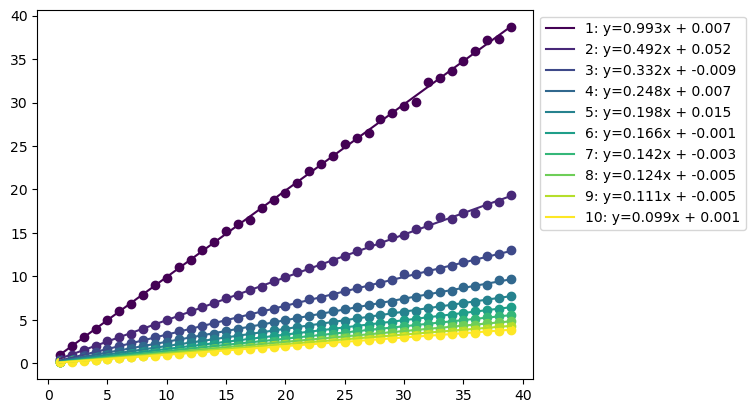

In [121]:
colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(n_years_list)))

fig, ax = plt.subplots()

for y, n_years in enumerate(n_years_list):
    variances = np.array(list(dict_mean_poisson[n_years]))**2.0
    # Calculate line end points:
    m = dict_mean_poisson_lines[n_years]['m']
    c = dict_mean_poisson_lines[n_years]['c']
    # y0 = m * locs[0] + c
    # y1 = m * locs[-1] + c

    label = f'{n_years}: y={m:.3f}x + {c:.3f}'
    
    ax.scatter(locs, variances, color=colours[y])
    ax.plot(locs, m*locs+c, color=colours[y], label=label)

ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
plt.show()

Show that variance factor is 1/_n_ for _n_ sets of observations:

In [122]:
for y, n_years in enumerate(n_years_list):
    print(f'{n_years:2d}, {1.0 / n_years:.3f}, {dict_mean_poisson_lines[n_years]["m"]:.3f}')

 1, 1.000, 0.993
 2, 0.500, 0.492
 3, 0.333, 0.332
 4, 0.250, 0.248
 5, 0.200, 0.198
 6, 0.167, 0.166
 7, 0.143, 0.142
 8, 0.125, 0.124
 9, 0.111, 0.111
10, 0.100, 0.099


The small errors in the generated numbers will be due to the fits. We can ignore the y-intercept of the linear regression fits because the values are much smaller than the gradients.

Show that the generated data averaged across three years fits the new variance better than standard Poisson distribution:

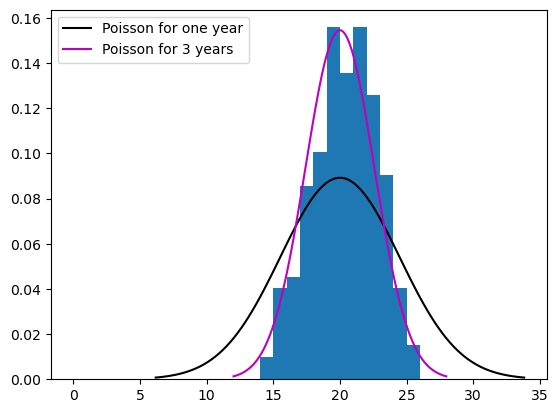

In [123]:
np.random.seed(42)

loc = 20
n_years = 3
n_samples = 200

s = [rng.poisson(loc, n_samples) for i in range(n_years)]
sav = np.mean(s, axis=0)

# Poisson for one year:
scale = np.sqrt(loc)
# Create normal distribution coordinates:
norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=scale),
                     norm.ppf(0.999, loc=loc, scale=scale), 100)
norm_y = norm.pdf(norm_x, loc=loc, scale=scale)

# Poisson for multiple years:
scale2 = np.sqrt(loc / n_years)
# Create normal distribution coordinates:
norm_x2 = np.linspace(norm.ppf(0.001, loc=loc, scale=scale2),
                     norm.ppf(0.999, loc=loc, scale=scale2), 100)
norm_y2 = norm.pdf(norm_x2, loc=loc, scale=scale2)



fig, ax = plt.subplots()
ax.hist(sav, bins=np.arange(0, np.ceil(max(sav)), 1), density=True)
ax.plot(norm_x, norm_y, color='k', label='Poisson for one year')
ax.plot(norm_x2, norm_y2, color='m', label=f'Poisson for {n_years} years')
ax.legend()
plt.show()

## Compare observed data with Poisson

Check means vs variances:

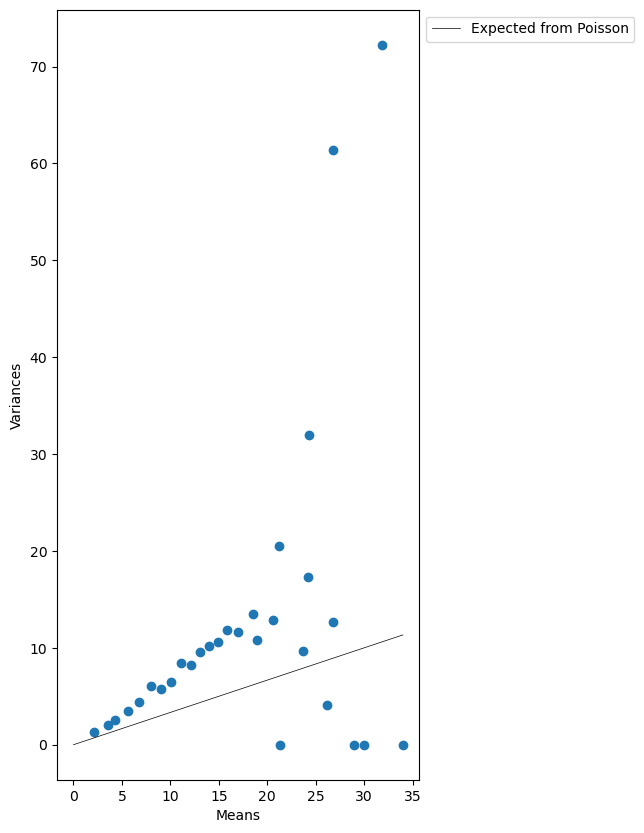

In [77]:
fig, ax = plt.subplots(figsize=(6, 10))

ax.scatter(df_bin_stats['means'], df_bin_stats['variances'])

# xmax = max([df_bin_stats['means'].max(), df_bin_stats['variances'].max()])
# ymax = xmax / 3.0
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['bin_mids'] / 3.0, color='k', linewidth=0.5, label='Expected from Poisson')

ax.set_aspect('equal')
ax.set_xlabel('Means')
ax.set_ylabel('Variances')
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

Plot the means and standard deviations over the original scatter plot. The horizontal lines show where the edges of the bins are, so all scatter points between two adjacent lines are placed into the same bin because they are said to have the same predicted admissions number when rounded.

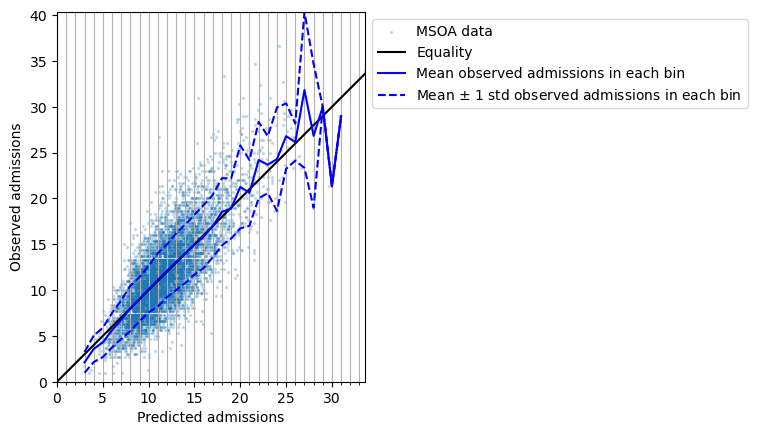

In [29]:
fig, ax = plt.subplots()

# Scatter admissions as usual:
ax.scatter(predicted_all, observed_all, s=2, alpha=0.2, label='MSOA data')
# Equality line:
ax.plot([0, max(observed_all)], [0, max(observed_all)],
        color='k', label='Equality')
# Plot mean +- std as lines:
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['means'], 
        color='b', label='Mean observed admissions in each bin')
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['means'] + df_bin_stats['stds'],
        linestyle='--', color='b',
        label=r'Mean $\pm$ 1 std observed admissions in each bin')
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['means'] - df_bin_stats['stds'], 
        linestyle='--', color='b', label=None)

# Set axis limits and make it square:
ax.set_aspect('equal')
ax.set_ylim(0, max(observed_all))
ax.set_xlim(0, max(predicted_all))
# Add a grid to help pick out where the bins are:
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.grid(axis='x', which='both')

# Labels:
ax.set_ylabel('Observed admissions')
ax.set_xlabel('Predicted admissions')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.savefig(os.path.join('images', 'uncertainty_binned_mean_std.png'), bbox_inches='tight', dpi=200)
plt.show()

The mean line (solid blue) follows the equality line (predicted exactly equal to observed admissions) quite well when the predicted admissinos are around 8 to 17. Above and below this range the mean is more erratic, likely because there are fewer data points in those areas.

It looks like the std lines are spaced more closely to the mean line for smaller predicted admissions (lower down on the chart) than they are for larger predicted admissions (higher up).

Next, take a closer look at the distribution of observed admissions in each bin. In the following figure, plot a bar chart of the values in each bin that has at least 5 admissions. This cutoff will remove the more erratic areas of the above chart - it means we will only plot bins with predicted admissions from 4 to 26 inclusive.

On top of each bar chart we also plot a normal distribution with the same mean and standard deviation as the values in the bin. The normal distribution has more values near the mean and fewer values that are much larger or smaller than the mean, like we expect to see in the admissions data.

 4 1.15 1.44 2.00 1.25
 5 1.29 1.59 2.24 1.23
 6 1.41 1.87 2.45 1.32
 7 1.53 2.10 2.65 1.38
 8 1.63 2.46 2.83 1.51
 9 1.73 2.40 3.00 1.39
10 1.83 2.54 3.16 1.39
11 1.91 2.91 3.32 1.52
12 2.00 2.87 3.46 1.43
13 2.08 3.09 3.61 1.49
14 2.16 3.20 3.74 1.48
15 2.24 3.26 3.87 1.46
16 2.31 3.44 4.00 1.49
17 2.38 3.41 4.12 1.43
18 2.45 3.67 4.24 1.50
19 2.52 3.29 4.36 1.31
20 2.58 4.53 4.47 1.75
21 2.65 3.59 4.58 1.36
22 2.71 4.17 4.69 1.54
23 2.77 3.11 4.80 1.12
24 2.83 5.65 4.90 2.00
25 2.89 3.56 5.00 1.23
26 2.94 2.02 5.10 0.69


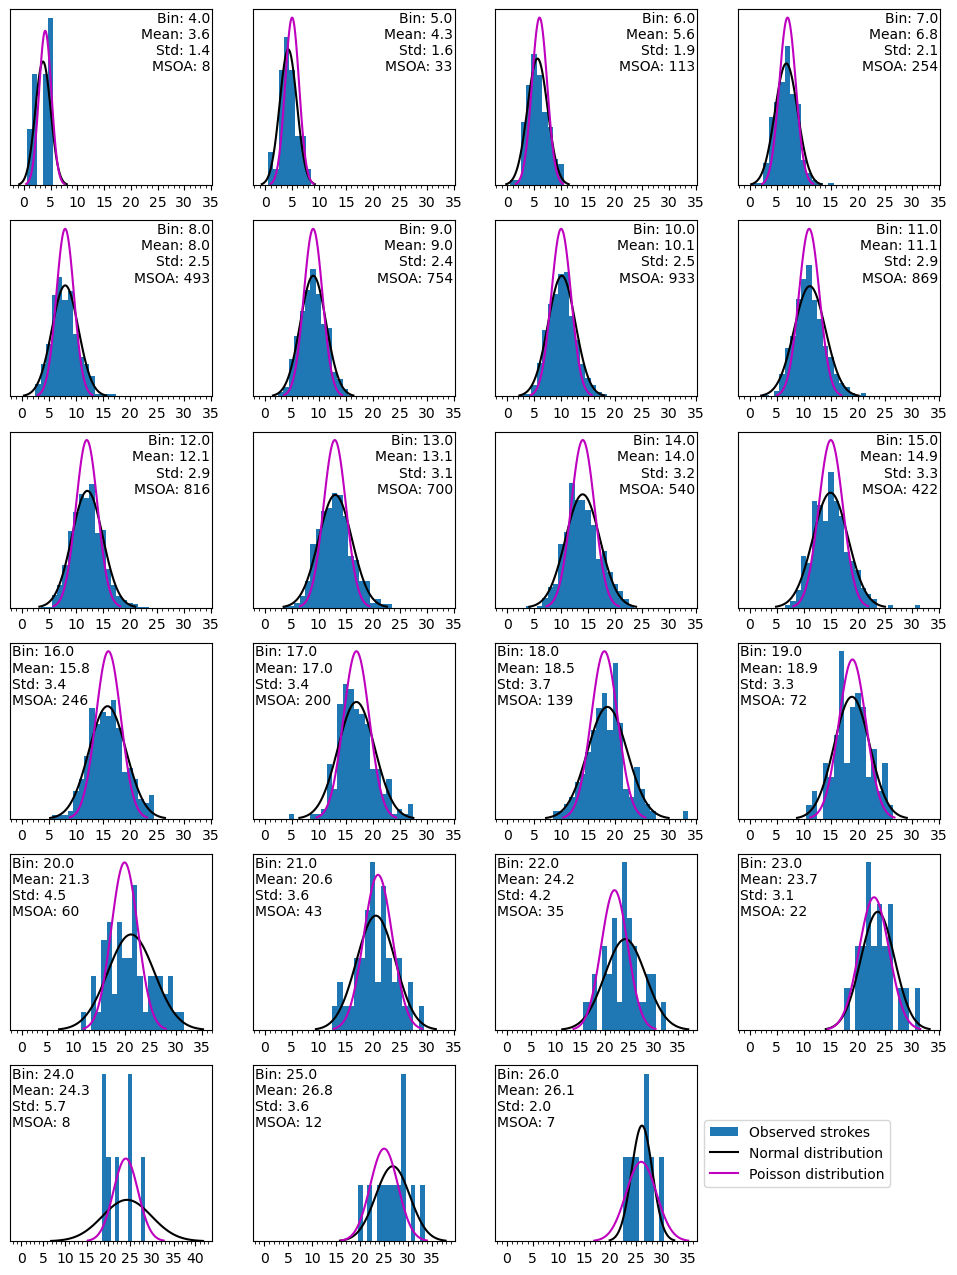

In [99]:
fig, axs = plt.subplots(6, 4, figsize=(12, 16))

# Only use bins that contain at least 5 MSOA:
df = df_bin_stats.filter(df_bin_stats['lengths'] >= 5)
# Plot each bin in turn:
for i in range(len(df)):
    # Select next available axis:
    ax = axs[i // 4, i % 4,]
    # Pick out data:
    b = df['bin_mids'][i]
    mean = df['means'][i]
    std = df['stds'][i]
    loc = b
    # scale = std
    scale = np.sqrt(loc / 3.0)
    print(f'{b:2.0f} {scale:.2f} {std:.2f} {np.sqrt(loc):.2f} {std / scale:.2f}')
    admissions_here = binned_admissions[b]


    # Create normal distribution coordinates:
    norm_x = np.linspace(norm.ppf(0.001, loc=mean, scale=std),
                         norm.ppf(0.999, loc=mean, scale=std), 100)
    norm_y = norm.pdf(norm_x, loc=mean, scale=std)
    # Create second dist from expected std:
    norm_x2 = np.linspace(norm.ppf(0.001, loc=loc, scale=scale),
                         norm.ppf(0.999, loc=loc, scale=scale), 100)
    norm_y2 = norm.pdf(norm_x2, loc=loc, scale=scale)
    # norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=np.sqrt(loc)),
    #                      norm.ppf(0.999, loc=loc, scale=np.sqrt(loc)), 100)
    # norm_y = norm.pdf(norm_x, loc=loc, scale=np.sqrt(loc))

    # Bar chart:
    ax.hist(admissions_here, bins=bins, density=True, label='Observed strokes')
    # Mark expected mean:
    # ax.scatter(b, max(norm_y), marker='x', color='r', linestyle='-', label='Predicted strokes')
    # # Mark one standard deviation from the mean:
    # ax.axvline(loc, color='k', linestyle='--', label='Mean')
    # ax.axvline(loc + scale, color='k', linestyle=':', label=r'Mean $\pm$ 1 std')
    # ax.axvline(loc - scale, color='k', linestyle=':', label=None)
    # Normal dist:
    ax.plot(norm_x, norm_y, color='k', label='Normal distribution')
    ax.plot(norm_x2, norm_y2, color='m', label='Poisson distribution')

    # Remove y ticks and labels.
    ax.set_yticks([])
    # Mark bin edges:
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))

    # Label each plot with the mean and std of the normal dist
    # as well as how many MSOA are in the bin.
    label = f'Bin: {b}' + '\n' + f'Mean: {mean:.1f}' + '\n' + f'Std: {std:.1f}' + '\n' + f'MSOA: {df["lengths"][i]}'
    # Draw the label on either the top left or the top right
    # depending on where there's room:
    if i < 12:
        ax.annotate(label, xy=(0.99, 0.99), va='top', ha='right', xycoords='axes fraction')
    else:
        ax.annotate(label, xy=(0.01, 0.99), va='top', ha='left', xycoords='axes fraction')
    
    # If this is the last graph then draw the legend in the
    # gap left by the empty axis.
    if i == 22:
        ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])

# Remove the unwanted final axis:
axs[-1, -1].set_visible(False)

plt.savefig(os.path.join('images', 'uncertainty_observed_admissions_variance.png'), bbox_inches='tight', dpi=200)
plt.show()

From the above histograms, see that the data fits best to the normal distribution when where are at least 200 MSOA in the sample. These ones consistently have a good match between the predicted admissions integer (red cross) and the top centre of the curve (solid line). This means that the mean of the observed admissions is close to the predicted admissions bin centre.

We can use the bins where the normal distribution matches well to find a general trend of standard deviation size with predicted admissions. This will let us define a new model mean and standard deviation for the bins where currently the fit is poor.

## Mean-std fit

From the scatter plot above, we expect that the standard deviation size should increase with the predicted admissions. This means that we can first try to fit an Ordinary Least Squares (OLS) linear regression to the data. Graphically this is finding the best straight line that predicts standard deviation given only the bin number.

To find the best model, use only the bins with at least 200 MSOAs:

In [65]:
df_ols = df_bin_stats.filter(df_bin_stats['lengths'] >= 200)

View the range of bins used:

In [66]:
print(df_ols['bin_mids'].min(), df_ols['bin_mids'].max())

7.0 17.0


Link the means and stds using Ordinary Least Squares fit:

In [67]:
# Value we're predicting:
Y = df_ols['stds'].to_numpy()
# Value we know:
X = df_ols['bin_mids'].to_numpy()
# Allow a constant so fit is of form "y = mx + c".
X = sm.add_constant(X)

# Fit the data to the model:
model = sm.OLS(Y,X)
results = model.fit()

View the resulting model parameters:

In [68]:
ols_m = results.params[1]
ols_c = results.params[0]

print(f'Gradient:    {ols_m:.4f}')
print(f'y-intercept: {ols_c:.4f}')

Gradient:    0.1319
y-intercept: 1.2986


The formula of the straight line is:

In [69]:
fit_label = f'y = {ols_m:.2f}x + {ols_c:.2f}'

fit_label

'y = 0.13x + 1.30'

Calculate r-squared:

In [70]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [71]:
stds_pred = ols_m * df_ols['bin_mids'].to_numpy() + ols_c

rsq = calculate_rsquared(df_ols['stds'].to_numpy(), stds_pred)

rsq

0.9542614517863761

Plot the variation of standard deviation with mean in the data. Also include the straight line fit to the data.

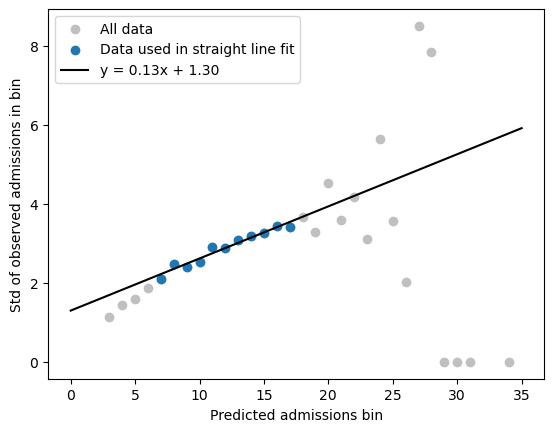

In [72]:
# Create coordinates for the straight line fit:
x = np.linspace(0, np.nanmax(df_bin_stats['bin_mids'])+1, 100)
y = ols_m*x + ols_c

fig, ax = plt.subplots()
# Display all bins in the background:
ax.scatter(df_bin_stats['bin_mids'], df_bin_stats['stds'], color='silver', label='All data')
# Display only the bins used in the fit more prominently:
ax.scatter(df_ols['bin_mids'], df_ols['stds'], label='Data used in straight line fit')
# Draw the straight line fit of mean to std:
ax.plot(x, y, color='k', label=fit_label)

ax.set_xlabel('Predicted admissions bin')
ax.set_ylabel('Std of observed admissions in bin')
ax.legend()

plt.savefig(os.path.join('images', 'uncertainty_linear_regression_std.png'), bbox_inches='tight', dpi=200)
plt.show()

The straight line fit is a good match to the data for the bins with at least 200 MSOA.

## Check Poisson from bin means

## Generate model standard deviations

Use the formula above with the predicted admissions bins to estimate the std for each bin.

In [78]:
# Calculate new standard deviations:
binned_stds_model = ols_m * df_bin_stats['bin_mids'] + ols_c

# Place it in the same dataframe as earlier:
df_bin_stats = df_bin_stats.with_columns(pl.Series('std_model', binned_stds_model))

View the results:

In [79]:
with pl.Config(set_tbl_rows=len(df_bin_stats)):
    display(df_bin_stats)

bin_mids,means,stds,variances,lengths,std_model
f64,f64,f64,f64,i64,f64
0.0,NaN,NaN,NaN,0,1.298589
1.0,NaN,NaN,NaN,0,1.430443
2.0,NaN,NaN,NaN,0,1.562298
3.0,2.111111,1.133115,1.283951,3,1.694152
4.0,3.583333,1.440968,2.076389,8,1.826007
5.0,4.292929,1.592824,2.537088,33,1.957861
6.0,5.622419,1.871225,3.501484,113,2.089715
7.0,6.76378,2.103037,4.422765,254,2.22157
8.0,8.010818,2.464692,6.074708,493,2.353424


Plot new fitted standard deviations over the predicted-observed admissions scatter:

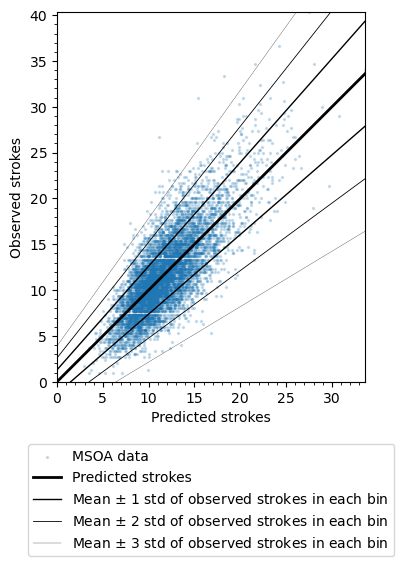

In [80]:
fig, ax = plt.subplots()

# Admissions data:
ax.scatter(predicted_all, observed_all, s=2, alpha=0.2, label='MSOA data')
# Equality line:
# ax.plot([0, max(observed_all)], [0, max(observed_all)], color='k', label='Equality')
# Mean +- std fit:
ax.plot(df_bin_stats['bin_mids'], df_bin_stats['bin_mids'],
        color='k', label='Predicted strokes', linewidth=2)

linewidths = [1.0, 0.6, 0.2]
for i, m in enumerate(range(1, 4)):
    ax.plot(
        df_bin_stats['bin_mids'],
        df_bin_stats['bin_mids'] + m * df_bin_stats['std_model'],
        linewidth=linewidths[i],
        color='k',
        label=r'Mean $\pm$ ' + f'{m:.0f}' + ' std of observed strokes in each bin',
    )
    ax.plot(
        df_bin_stats['bin_mids'],
        df_bin_stats['bin_mids'] - m * df_bin_stats['std_model'],
        linewidth=linewidths[i],
        color='k',
    )
 
# Set axis limits and make it square:
ax.set_aspect('equal')
ax.set_ylim(0, max(observed_all))
ax.set_xlim(0, max(predicted_all))
# Add a grid to help pick out where the bins are:
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
# ax.grid(axis='y', which='both')

# Labels:
ax.set_ylabel('Observed strokes')
ax.set_xlabel('Predicted strokes')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.savefig(os.path.join('images', 'uncertainty_fitted_std.png'), bbox_inches='tight', dpi=200)
plt.show()

Allowing two standard deviations either side of the mean (horizontally left or right from the central line) does cover most of the points.

## Total admissions for England

Is the observed total admissions value within the uncertainty of the predicted total admissions value?

Calculate the total admissions:

In [81]:
total_admissions_observed = sum(observed_all)
total_admissions_predicted = sum(predicted_all)

print(f'Total admissions (observed):  {total_admissions_observed:.1f}')
print(f'Total admissions (predicted): {total_admissions_predicted:.1f}')

Total admissions (observed):  80958.0
Total admissions (predicted): 80553.4


Calculate the standard deviation associated with each MSOA:

In [82]:
stds_predicted = ols_m * np.array(predicted_all) + ols_c

Combine the separate standard deviations into one final value. Take the sum of the square stds for all MSOA and then square root the result:

In [83]:
total_uncert = np.sqrt(np.sum(stds_predicted**2.0))

print(f'{total_uncert:.1f}')

238.7


How big is this uncertainty compared with the total admissions?

In [84]:
print(f'{100.0 * total_uncert / total_admissions_predicted:.1f}%')

0.3%


This uncertainty is quite small. Unreasonably small?

Add and subtract this from the total predicted admissions:

In [85]:
total_admissions_predicted_low = total_admissions_predicted - total_uncert
total_admissions_predicted_top = total_admissions_predicted + total_uncert

print(f'Range of predicted admissions: {total_admissions_predicted_low:.1f} to {total_admissions_predicted_top:.1f}')

Range of predicted admissions: 80314.7 to 80792.1


The total observed admissions is _not quite_ in this range of values.

This indicates that we should have taken more uncertainties into account when calculating those values. For example, we don't know how typical the real observed admissions data is - maybe with more years' data to reduce the effect of any outliers, the final match in admissions numbers would be better. We also don't have access to any uncertainty in the population data (the number of people in each age band). We don't know how accurate all of the assumptions made were, for example scaling up the admissions numbers by age band in SSNAP to match the total admissions in HES might be a poor assumption if the missing data is more skewed towards particular age bands for some reason. Perhaps we should be feeding through some uncertainty on the values of the coefficients too, but that would make the total uncertainty huge.

## Effect of nudging coeffs

Calculate the number of people in each combination of deprivation and age band:

In [86]:
dict_total_persons = {}

for i, lists_by_depriv_band in enumerate(x_lists):
    q_here = quantile_str_list[i]
    for lists_by_age in lists_by_depriv_band:
        age_band = lists_by_age.name
        n_people = lists_by_age.sum()
        dict_total_persons[f'{age_band}_{q_here}'] = n_people

In [87]:
arr_total_persons = np.array(list(dict_total_persons.values())).reshape(5, 5)

arr_total_persons

array([[9924432.9305    ,  454870.6392    ,  408533.6541    ,
         282735.5075    ,  404335.3945    ],
       [9602442.0019    ,  508547.6151    ,  490250.9899    ,
         346299.4298    ,  492042.4994    ],
       [9004763.90820001,  582915.6219    ,  595289.7078    ,
         423567.5196    ,  593857.2014    ],
       [8520385.1629    ,  615871.6872    ,  650064.9713    ,
         468822.7434    ,  657198.8848    ],
       [8544149.7571    ,  598979.519     ,  647016.1588    ,
         472220.0104    ,  685473.2984    ]])

How many admissions come from each of these groups according to the final coefficients?

In [88]:
admissions_by_group = arr_total_persons * best_coeffs.reshape(5, 5)

admissions_by_group

array([[5954.6597583 , 2274.353196  , 2042.6682705 , 1979.1485525 ,
        4852.024734  ],
       [4801.22100095, 1525.6428453 , 1961.0039596 , 2424.0960086 ,
        5904.5099928 ],
       [2701.42917246, 1165.8312438 , 2381.1588312 , 2541.4051176 ,
        7126.2864168 ],
       [2556.11554887, 1231.7433744 , 2600.2598852 , 2344.113717  ,
        7229.1877328 ],
       [2563.24492713, 1197.959038  , 1294.0323176 , 2361.100052  ,
        7540.2062824 ]])

What's the effect on the admission numbers if each coeff were one click higher or lower?

Calculate the nudged coefficients:

In [89]:
best_coeffs_up = np.array([c for c in best_coeffs]).reshape(5, 5)
best_coeffs_up[:, 0] += 1e-4
best_coeffs_up[:, 1:] += 1e-3

best_coeffs_down = np.array([c for c in best_coeffs]).reshape(5, 5)
best_coeffs_down[:, 0] -= 1e-4
best_coeffs_down[:, 1:] -= 1e-3

print(best_coeffs_up)
print('')
print(best_coeffs.reshape(5, 5))
print('')
print(best_coeffs_down)

[[0.0007 0.006  0.006  0.008  0.013 ]
 [0.0006 0.004  0.005  0.008  0.013 ]
 [0.0004 0.003  0.005  0.007  0.013 ]
 [0.0004 0.003  0.005  0.006  0.012 ]
 [0.0004 0.003  0.003  0.006  0.012 ]]

[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]

[[0.0005 0.004  0.004  0.006  0.011 ]
 [0.0004 0.002  0.003  0.006  0.011 ]
 [0.0002 0.001  0.003  0.005  0.011 ]
 [0.0002 0.001  0.003  0.004  0.01  ]
 [0.0002 0.001  0.001  0.004  0.01  ]]


How many people does this give in total?

In [90]:
print(f'Total for nudged up:   {np.sum((arr_total_persons * best_coeffs_up)):.1f}')
print(f'Total for best coeffs: {np.sum((arr_total_persons * best_coeffs.reshape(5, 5))):.1f}')
print(f'Total for nudged down: {np.sum((arr_total_persons * best_coeffs_down)):.1f}')

Total for nudged up:   95491.9
Total for best coeffs: 80553.4
Total for nudged down: 65614.9


The total change is around 15,000 admissions or 19% of the total.

Check how this affects each age/deprivation combination separately. Multiply coefficients by total population:

In [91]:
print((arr_total_persons * best_coeffs_up) - admissions_by_group)
print('')
print((arr_total_persons * best_coeffs_down) - admissions_by_group)

[[992.44329305 454.8706392  408.5336541  282.7355075  404.3353945 ]
 [960.24420019 508.5476151  490.2509899  346.2994298  492.0424994 ]
 [900.47639082 582.9156219  595.2897078  423.5675196  593.8572014 ]
 [852.03851629 615.8716872  650.0649713  468.8227434  657.1988848 ]
 [854.41497571 598.979519   647.0161588  472.2200104  685.4732984 ]]

[[-992.44329305 -454.8706392  -408.5336541  -282.7355075  -404.3353945 ]
 [-960.24420019 -508.5476151  -490.2509899  -346.2994298  -492.0424994 ]
 [-900.47639082 -582.9156219  -595.2897078  -423.5675196  -593.8572014 ]
 [-852.03851629 -615.8716872  -650.0649713  -468.8227434  -657.1988848 ]
 [-854.41497571 -598.979519   -647.0161588  -472.2200104  -685.4732984 ]]


Adding or subtracting one click from each coefficient has an effect on the order of half a thousand admissions (0.6% of England total) for all coeffs except the under-65 age band where the effect is nearer one thousand admissions (1.3% of England total). This is why it was good to have the option of moving one coefficient up by one click and another down by two clicks: some of the coefficients have twice the effect on total admissions as others.

Show these as percentage changes:

In [92]:
print(100.0 * ((arr_total_persons * best_coeffs_up) - admissions_by_group) / admissions_by_group)
print('')
print(100.0 * ((arr_total_persons * best_coeffs_down) - admissions_by_group) / admissions_by_group)

[[16.66666667 20.         20.         14.28571429  8.33333333]
 [20.         33.33333333 25.         14.28571429  8.33333333]
 [33.33333333 50.         25.         16.66666667  8.33333333]
 [33.33333333 50.         25.         20.          9.09090909]
 [33.33333333 50.         50.         20.          9.09090909]]

[[-16.66666667 -20.         -20.         -14.28571429  -8.33333333]
 [-20.         -33.33333333 -25.         -14.28571429  -8.33333333]
 [-33.33333333 -50.         -25.         -16.66666667  -8.33333333]
 [-33.33333333 -50.         -25.         -20.          -9.09090909]
 [-33.33333333 -50.         -50.         -20.          -9.09090909]]


This is an uneven effect throughout... The percentage change depends not just on the size of the change, but also the size of the coefficient to begin with.

## Conclusion

We can use this fitted standard deviation format as a measure of accuracy. For predicted admissions $x$, the std $s$ is $s = 0.13x + 1.30$ so the size of the standard deviation increases with the number of predicted admissions.

For generating admissions numbers with some variation from the single predicted value, we can sample a Poisson distribution with a mean of the predicted admissions and a standard deviation from the formula.